# Семинар 1. Линейная регрессия

#### Шаг 1. Загрузка датасета и вывод на экран

In [22]:
import pandas as pd

# Загружаем датасет
df = pd.read_csv('delivery_dataset.csv')

print('Размер датасета:', df.shape)
display(df.head())


Размер датасета: (500, 8)


,Дата заказа (ГГГГ-ММ-ДД),Шифр заказа (ID),Расстояние до клиента (в км),Количество позиций в чеке (в шт.),Балл пробок на дорогах (в баллах),Погода (в градусах Цельсия),Этаж доставки (в этажах),Время доставки (в минутах)
0,2026-09-08,ORD-202608001,11.3,1,9,21.0,6,79.2
1,2026-08-29,ORD-202608002,7.3,3,7,27.0,7,46.6
2,2026-08-15,ORD-202608003,2.2,1,3,20.0,5,16.3
3,2026-08-08,ORD-202608004,0.9,2,6,22.9,1,15.8
4,2026-08-21,ORD-202608005,12.3,14,4,18.1,2,69.2


#### Шаг2. Разделение выборки на тренировочную, валидационную и тестовую с выбором нужных столбцов:
* в тренировочной: 300 первых заказов;
* в валидационной: 100 следующих; 
* в тестовой: 100 последних.

In [23]:
feature_cols = [
    'Расстояние до клиента (в км)',
    'Количество позиций в чеке (в шт.)',
    'Балл пробок на дорогах (в баллах)',
    'Погода (в градусах Цельсия)',
    'Этаж доставки (в этажах)'
]
target_col = 'Время доставки (в минутах)'

X = df[feature_cols]
y = df[target_col]

X_train, y_train = X.iloc[:300], y.iloc[:300]
X_val, y_val = X.iloc[300:400], y.iloc[300:400]
X_test, y_test = X.iloc[400:500], y.iloc[400:500]

print('Train:', X_train.shape, y_train.shape)
print('Validation:', X_val.shape, y_val.shape)
print('Test:', X_test.shape, y_test.shape)


Train: (300, 5) (300,)
Validation: (100, 5) (100,)
Test: (100, 5) (100,)


#### Вопрос 1. 

Для чего мы разбиваем данные на выборки? Для чего нам нужна тренировачная, для чего валидационная, для чего тестовая?

чтобы честно обучить и оценить модель. на тренировочной выборке модель учится, на валидационной подбирают параметры и проверяют качество во время разработки, а тестовая нужна для финальной оценки готовой модели, которую катим в прод.

#### Шаг 3. Установка sklearn чтобы обучать модель линейной регрессии через Ridge

In [24]:
# Если scikit-learn уже установлен, повторная установка не требуется.
# !pip install scikit-learn


#### Шаг 4. Обучение модели линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg

In [25]:
from sklearn.linear_model import Ridge

# Ridge — линейная регрессия с L2-регуляризацией.
# sparse_cg — итерационный решатель системы линейных уравнений.
model = Ridge(
    alpha=1.0,
    solver='sparse_cg',
    max_iter=100,
    tol=1e-12
)

model.fit(X_train, y_train)

print('Свободный коэффициент:', model.intercept_)
print('Коэффициенты модели:')
for feature, coef in zip(feature_cols, model.coef_):
    print(f'{feature}: {coef:.4f}')


Свободный коэффициент: -2.9565871580551146
Коэффициенты модели:
Расстояние до клиента (в км): 4.3957
Количество позиций в чеке (в шт.): 0.8351
Балл пробок на дорогах (в баллах): 2.1524
Погода (в градусах Цельсия): -0.0473
Этаж доставки (в этажах): 0.3432


#### Шаг 5. Вывод на экран графиков ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок.

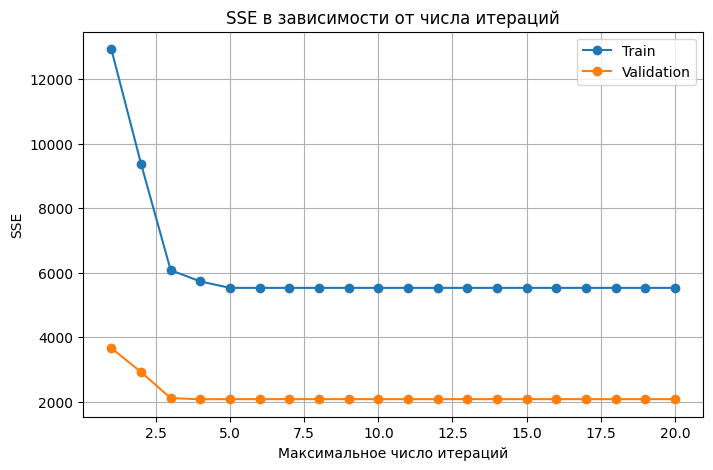

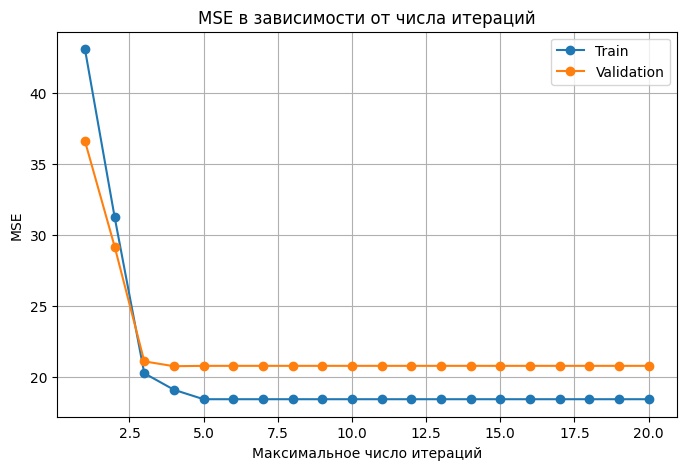

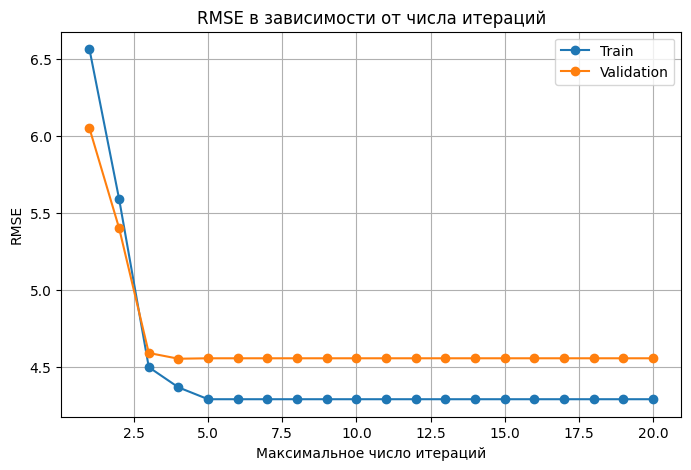

Минимальный RMSE на validation: 4.5560 при max_iter=4


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.exceptions import ConvergenceWarning
import warnings

iterations = range(1, 21)

train_sse, val_sse = [], []
train_mse, val_mse = [], []
train_rmse, val_rmse = [], []

for max_iter in iterations:
    current_model = Ridge(
        alpha=1.0,
        solver='sparse_cg',
        max_iter=max_iter,
        tol=1e-12
    )

    with warnings.catch_warnings():
        warnings.simplefilter('ignore', ConvergenceWarning)
        warnings.simplefilter("ignore", RuntimeWarning)
        current_model.fit(X_train, y_train)

        train_pred = current_model.predict(X_train)
        val_pred = current_model.predict(X_val)

    train_errors = y_train.to_numpy() - train_pred
    val_errors = y_val.to_numpy() - val_pred

    train_sse.append(np.sum(train_errors ** 2))
    val_sse.append(np.sum(val_errors ** 2))

    train_mse.append(mean_squared_error(y_train, train_pred))
    val_mse.append(mean_squared_error(y_val, val_pred))

    train_rmse.append(np.sqrt(train_mse[-1]))
    val_rmse.append(np.sqrt(val_mse[-1]))

plt.figure(figsize=(8, 5))
plt.plot(iterations, train_sse, marker='o', label='Train')
plt.plot(iterations, val_sse, marker='o', label='Validation')
plt.xlabel('Максимальное число итераций')
plt.ylabel('SSE')
plt.title('SSE в зависимости от числа итераций')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(iterations, train_mse, marker='o', label='Train')
plt.plot(iterations, val_mse, marker='o', label='Validation')
plt.xlabel('Максимальное число итераций')
plt.ylabel('MSE')
plt.title('MSE в зависимости от числа итераций')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(iterations, train_rmse, marker='o', label='Train')
plt.plot(iterations, val_rmse, marker='o', label='Validation')
plt.xlabel('Максимальное число итераций')
plt.ylabel('RMSE')
plt.title('RMSE в зависимости от числа итераций')
plt.grid(True)
plt.legend()
plt.show()

best_iter = int(np.argmin(val_rmse)) + 1
print(f'Минимальный RMSE на validation: {min(val_rmse):.4f} при max_iter={best_iter}')


#### Вопрос 2.

Какую информацию про нашу модель несут эти графики?

как меняется ошибка модели по итерациям. видно, что к 3 итерации ошибка резко уменьшается и дальше почти не меняется, то есть модель уже сошлась. ошибки на train и val близки, поэтому явного заметного переобучения нет.

#### Вопрос 3. 

Какая траектория линий train и val ошибок будет на графиках недообученной модели и почему?

Какая траектория линий train и val ошибок будет на графиках обученной модели и почему?

Какая траектория линий train и val ошибок будет на графиках переобученной модели и почему?

у недообученной модели train и val ошибки высокие и обычно обе от итерации к итерации снижаются, потому что модель ещё не успела нормально выучить зависимости.  
у обученной модели train и val ошибки низкие и +- сопоставимы друг с другом, а их снижение почти прекращается, потому что модель уже сошлась и хорошо обобщает данные.  
у переобученной модели train ошибка снижается, а val ошибка после какого-то момента начинает расти, потому что модель подстраивается под train и хуже работает на новых данных.  

#### Шаг 6. Применение модели на тестовой выборке

In [27]:
# Применяем обученную модель к тестовой выборке
y_test_pred = model.predict(X_test)

result = pd.DataFrame({
    'Фактическое время': y_test.to_numpy(),
    'Предсказанное время': y_test_pred,
    'Ошибка': y_test.to_numpy() - y_test_pred
})

display(result.head(10))


,Фактическое время,Предсказанное время,Ошибка
0,33.9,33.063774,0.836226
1,33.1,33.127972,-0.027972
2,16.3,20.851544,-4.551544
3,34.7,34.388419,0.311581
4,13.3,17.564630,-4.264630
5,39.3,42.807987,-3.507987
6,36.3,37.449769,-1.149769
7,11.9,12.352370,-0.452370
8,56.5,59.053148,-2.553148
9,35.9,32.088040,3.811960


#### Шаг 7. RMSE на тестовой выборке

In [28]:
# RMSE на тестовой выборке
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print(f'RMSE на тестовой выборке: {test_rmse:.4f} минуты')


RMSE на тестовой выборке: 4.8316 минуты


#### Вопрос 4.

Что получившийся RMSE может сказать о нашей модели?

что в среднем прогноз времени доставки ошибается примерно на 4.8 минуты.
